<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
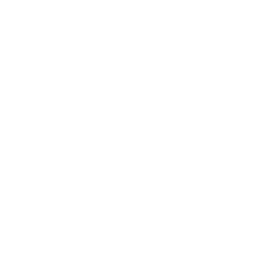
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Documentação do Esquema de Anotação de Variantes Genômicas</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Bioinformática / Gestão de Dados de Genômica Clínica &nbsp;|&nbsp; Março de 2026</p>
</div>
</div>
</div>

## Resumo Executivo

Documentar o esquema de conjuntos de dados de anotação de variantes no estilo VCF utilizados em um pipeline de genômica clínica. Utilize o PROC CONTENTS para catalogar todos os campos de anotação — coordenadas genômicas, frequências alélicas, efeitos funcionais previstos, classificações do ClinVar e métricas de qualidade — garantindo que as ferramentas de interpretação de variantes ACMG a jusante recebam entradas corretamente tipadas e rotuladas. Aproximadamente 5,000 registros de variantes com 20+ colunas de anotação são inspecionados quanto à integridade do esquema antes da transferência para o pipeline.

## Fontes de Dados

| Fonte | Descrição | Registros |
|--------|-------------|--------|
| VARIANT_ANNOTATIONS | Variantes anotadas derivadas de VCF | ~5,000 |
| GENE_PANEL | Definições do painel de genes-alvo | ~150 genes |
| QUALITY_METRICS | Controle de qualidade de sequenciamento por amostra | ~50 amostras |

---

In [1]:
/* --------------------------------------------------------
   Gera conjunto de dados de anotação de variantes no estilo VCF
   5.000 variantes com campos de anotação clínica
   -------------------------------------------------------- */
DADOS variant_annotations;
    CHAMAR streaminit(42);
    COMPRIMENTO variant_id $20 chromosome $5 position 8
           ref_allele $10 alt_allele $10 gene_symbol $15
           transcript_id $20 consequence $30
           impact $10 hgvs_c $25 hgvs_p $25
           gnomad_af 8 clinvar_class $25 clinvar_id $12
           sift_score 8 sift_pred $15
           polyphen_score 8 polyphen_pred $15
           cadd_phred 8 revel_score 8
           genotype $5 allele_depth 8 read_depth 8
           qual_score 8 filter_status $10;
    RÓTULO variant_id="Identificador da Variante"
          chromosome="Cromossomo"
          position="Posição Genômica (GRCh38)"
          ref_allele="Alelo de Referência"
          alt_allele="Alelo Alternativo"
          gene_symbol="Símbolo Gênico HGNC"
          transcript_id="ID de Transcrito Ensembl"
          consequence="Consequência (Sequence Ontology)"
          impact="Nível de Impacto Previsto"
          hgvs_c="Notação de Codificação HGVS"
          hgvs_p="Notação de Proteína HGVS"
          gnomad_af="Frequência Alélica gnomAD"
          clinvar_class="Classificação ClinVar"
          clinvar_id="Acesso ClinVar"
          sift_score="Escore SIFT"
          sift_pred="Predição SIFT"
          polyphen_score="Escore PolyPhen-2"
          polyphen_pred="Predição PolyPhen-2"
          cadd_phred="Escore CADD Phred"
          revel_score="Escore Ensemble REVEL"
          genotype="Genótipo da Amostra"
          allele_depth="Profundidade do Alelo Alternativo"
          read_depth="Profundidade Total de Leituras"
          qual_score="Escore de Qualidade da Variante"
          filter_status="Status do Filtro";
    VETOR genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    VETOR conseqs[6] $30 _temporary_ ('missense_variant'
        'synonymous_variant' 'frameshift_variant'
        'stop_gained' 'splice_donor_variant' 'intron_variant');
    VETOR impacts[6] $10 _temporary_ ('MODERATE' 'LOW' 'HIGH'
        'HIGH' 'HIGH' 'MODIFIER');
    VETOR cv_classes[5] $25 _temporary_ ('Pathogenic'
        'Likely_pathogenic' 'Uncertain_significance'
        'Likely_benign' 'Benign');
    VETOR refs[4] $1 _temporary_ ('A' 'C' 'G' 'T');
    VETOR gts[3] $5 _temporary_ ('0/1' '1/1' '0/0');
    FAZER i = 1 ATÉ 5000;
        variant_id = cat('VAR-', PUT(i, z8.));
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        position = int(rand('uniform') * 200000000) + 10000;
        r_idx = int(rand('uniform') * 4) + 1;
        a_idx = mod(r_idx, 4) + 1;
        ref_allele = refs[r_idx];
        alt_allele = refs[a_idx];
        g_idx = int(rand('uniform') * 15) + 1;
        gene_symbol = genes[g_idx];
        transcript_id = cat('ENST00000', PUT(int(rand('uniform') * 99999) + 100000, z6.));
        c_idx = int(rand('uniform') * 6) + 1;
        consequence = conseqs[c_idx];
        impact = impacts[c_idx];
        codon_pos = int(rand('uniform') * 2000) + 1;
        hgvs_c = cat('c.', PUT(codon_pos, 4.), ref_allele, '>', alt_allele);
        SE c_idx <= 2 ENTÃO
            hgvs_p = cat('p.', PUT(int(rand('uniform') * 800) + 1, 4.));
        SENÃO hgvs_p = 'p.?';
        gnomad_af = round(rand('beta', 0.5, 500), 0.000001);
        cv_idx = int(rand('uniform') * 5) + 1;
        clinvar_class = cv_classes[cv_idx];
        clinvar_id = cat('RCV', PUT(int(rand('uniform') * 900000) + 100000, z6.));
        sift_score = round(rand('uniform'), 0.001);
        SE sift_score < 0.05 ENTÃO sift_pred = 'DELETERIOUS';
        SENÃO sift_pred = 'TOLERATED';
        polyphen_score = round(rand('uniform'), 0.001);
        SE polyphen_score > 0.908 ENTÃO polyphen_pred = 'PROB_DAMAGING';
        SENÃO SE polyphen_score > 0.446 ENTÃO polyphen_pred = 'POSS_DAMAGING';
        SENÃO polyphen_pred = 'BENIGN';
        cadd_phred = round(rand('uniform') * 40, 0.01);
        revel_score = round(rand('uniform'), 0.001);
        gt_idx = int(rand('uniform') * 3) + 1;
        genotype = gts[gt_idx];
        read_depth = int(rand('uniform') * 200) + 20;
        allele_depth = int(read_depth * (0.3 + rand('uniform') * 0.4));
        qual_score = round(rand('uniform') * 5000 + 100, 0.1);
        filter_status = ifc(qual_score > 500, 'PASS', 'LOW_QUAL');
        SAÍDA;
    FIM;
    REMOVER i chr_num r_idx a_idx g_idx c_idx cv_idx gt_idx codon_pos;
EXECUTAR;


NOTE: DATA variant_annotations

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote variant_annotations (100 rows, 25 columns).
NOTE: DATA elapsed:
  wall  3.11 seconds
  cpu   3.11 seconds


In [2]:
/* --------------------------------------------------------
   Gera as definições do painel de genes-alvo
   -------------------------------------------------------- */
DADOS gene_panel;
    CHAMAR streaminit(42);
    COMPRIMENTO gene_symbol $15 gene_name $60 chromosome $5
           start_pos 8 end_pos 8 panel_name $30
           disease_association $50 inheritance $5;
    RÓTULO gene_symbol="Símbolo Gênico HGNC"
          gene_name="Nome Completo do Gene"
          chromosome="Cromossomo"
          start_pos="Posição Inicial do Gene"
          end_pos="Posição Final do Gene"
          panel_name="Painel Gênico Clínico"
          disease_association="Doença Associada"
          inheritance="Padrão de Herança";
    VETOR genes[15] $15 _temporary_ ('BRCA1' 'BRCA2' 'TP53' 'EGFR'
        'KRAS' 'PIK3CA' 'PTEN' 'APC' 'MLH1' 'MSH2' 'ATM'
        'CHEK2' 'PALB2' 'RAD51C' 'RAD51D');
    VETOR gnames[15] $60 _temporary_ (
        'BRCA1 DNA Repair Associated'
        'BRCA2 DNA Repair Associated'
        'Tumor Protein P53'
        'Epidermal Growth Factor Receptor'
        'KRAS Proto-Oncogene'
        'PI3-Kinase Catalytic Subunit Alpha'
        'Phosphatase and Tensin Homolog'
        'APC Regulator of WNT Signaling'
        'MutL Homolog 1'
        'MutS Homolog 2'
        'ATM Serine/Threonine Kinase'
        'Checkpoint Kinase 2'
        'Partner and Localizer of BRCA2'
        'RAD51 Paralog C'
        'RAD51 Paralog D');
    VETOR diseases[15] $50 _temporary_ (
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Li-Fraumeni Syndrome'
        'Non-Small Cell Lung Cancer'
        'Colorectal Cancer'
        'Breast Cancer'
        'Cowden Syndrome'
        'Familial Adenomatous Polyposis'
        'Lynch Syndrome'
        'Lynch Syndrome'
        'Ataxia-Telangiectasia'
        'Li-Fraumeni Syndrome'
        'Hereditary Breast Cancer'
        'Hereditary Breast/Ovarian Cancer'
        'Hereditary Breast/Ovarian Cancer');
    VETOR inhrt[15] $5 _temporary_ ('AD' 'AD' 'AD' 'AD' 'AD'
        'AD' 'AD' 'AD' 'AD' 'AD' 'AR' 'AD' 'AD' 'AD' 'AD');
    FAZER g = 1 ATÉ 15;
        gene_symbol = genes[g];
        gene_name = gnames[g];
        chr_num = int(rand('uniform') * 22) + 1;
        chromosome = cat('chr', PUT(chr_num, 2.));
        start_pos = int(rand('uniform') * 150000000) + 1000000;
        end_pos = start_pos + int(rand('uniform') * 100000) + 5000;
        panel_name = 'HEREDITARY_CANCER_V3';
        disease_association = diseases[g];
        inheritance = inhrt[g];
        SAÍDA;
    FIM;
    REMOVER g chr_num;
EXECUTAR;


NOTE: DATA gene_panel


NOTE: Wrote gene_panel (15 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


In [3]:
/* --------------------------------------------------------
   Gera as métricas de qualidade de sequenciamento por amostra
   -------------------------------------------------------- */
DADOS quality_metrics;
    CHAMAR streaminit(42);
    COMPRIMENTO sample_id $15 run_id $12 platform $15
           mean_coverage 8 pct_target_20x 8 pct_target_100x 8
           total_variants 8 ti_tv_ratio 8 het_hom_ratio 8
           contamination_est 8 qc_status $10;
    RÓTULO sample_id="Identificador da Amostra"
          run_id="ID da Corrida de Sequenciamento"
          platform="Plataforma de Sequenciamento"
          mean_coverage="Cobertura Média do Alvo"
          pct_target_20x="Percentual de Bases >= 20x"
          pct_target_100x="Percentual de Bases >= 100x"
          total_variants="Total de Variantes Identificadas"
          ti_tv_ratio="Razão Transição/Transversão"
          het_hom_ratio="Razão Het/Hom"
          contamination_est="Contaminação Estimada"
          qc_status="Status de QC (Aprovado/Reprovado)";
    FAZER s = 1 ATÉ 50;
        sample_id = cat('SAMP-', PUT(s, z6.));
        run_id = cat('RUN-', PUT(int((s - 1) / 10) + 1, z4.));
        platform = 'ILLUMINA_NOVA';
        mean_coverage = round(250 + rand('normal') * 50, 0.1);
        pct_target_20x = round(MIN(99.5, 95 + rand('uniform') * 4.5), 0.01);
        pct_target_100x = round(MIN(98, 85 + rand('uniform') * 13), 0.01);
        total_variants = int(rand('uniform') * 2000) + 3000;
        ti_tv_ratio = round(2.0 + rand('normal') * 0.15, 0.01);
        het_hom_ratio = round(1.5 + rand('normal') * 0.2, 0.01);
        contamination_est = round(MAX(0, rand('uniform') * 0.02), 0.0001);
        SE mean_coverage < 150 OU pct_target_20x < 95
            OU contamination_est > 0.015 ENTÃO qc_status = 'FAIL';
        SENÃO qc_status = 'PASS';
        SAÍDA;
    FIM;
    REMOVER s;
EXECUTAR;


NOTE: DATA quality_metrics


NOTE: Wrote quality_metrics (50 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


---

                                     Impacto da Variante por Classificação ClinVar                                      

                                                   The FREQ Procedure

Table of Nível de Impacto Previsto by Classificação ClinVar

Nível de Impacto Previsto  |                Benign |         Likely_benign |     Likely_pathogenic |            Pathogenic |Uncertain_significance |                  Total
---------------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------+-----------------------
HIGH                       |                     9 |                    10 |                    19 |                    12 |                    12 |                     62
                           |                  9.00 |                 10.00 |                 19.00 |                 12.00 |                 12.00 |                  62.00
                           |                 14.52 |      


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_impact_clinvar_class.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


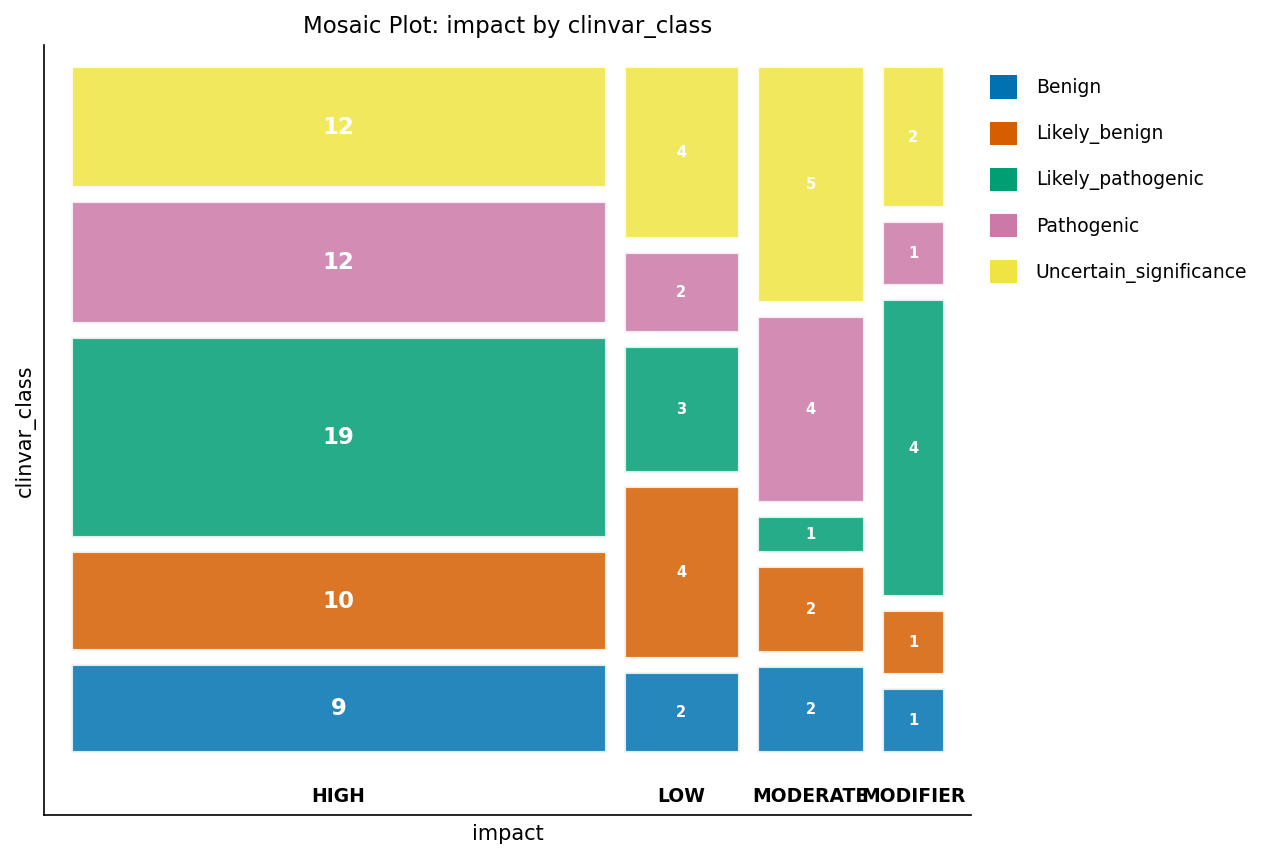

In [4]:
/* --------------------------------------------------------
   Resumo de referência da anotação de variantes
   -------------------------------------------------------- */
PROCEDIMENTO FREQUÊNCIAS DADOS=variant_annotations;
    TABLES impact * clinvar_class / nocum;
    RÓTULO impact="Nível de Impacto Previsto"
          clinvar_class="Classificação ClinVar";
    TÍTULO "Impacto da Variante por Classificação ClinVar";
EXECUTAR;

PROCEDIMENTO MÉDIAS DADOS=quality_metrics n mean MIN MAX;
    VARIÁVEL mean_coverage ti_tv_ratio contamination_est;
    RÓTULO mean_coverage="Cobertura Média do Alvo"
          ti_tv_ratio="Razão Transição/Transversão"
          contamination_est="Contaminação Estimada";
    TÍTULO "Resumo das Métricas de Qualidade de Sequenciamento";
EXECUTAR;

---

                                   Resumo das Métricas de Qualidade de Sequenciamento                                   

                                   Resumo das Métricas de Qualidade de Sequenciamento                                   




NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=schema_lengths created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: DATA schema_lengths


NOTE: Read 25 rows from schema_lengths.
NOTE: Wrote schema_lengths (25 rows, 17 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=schema_lengths

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


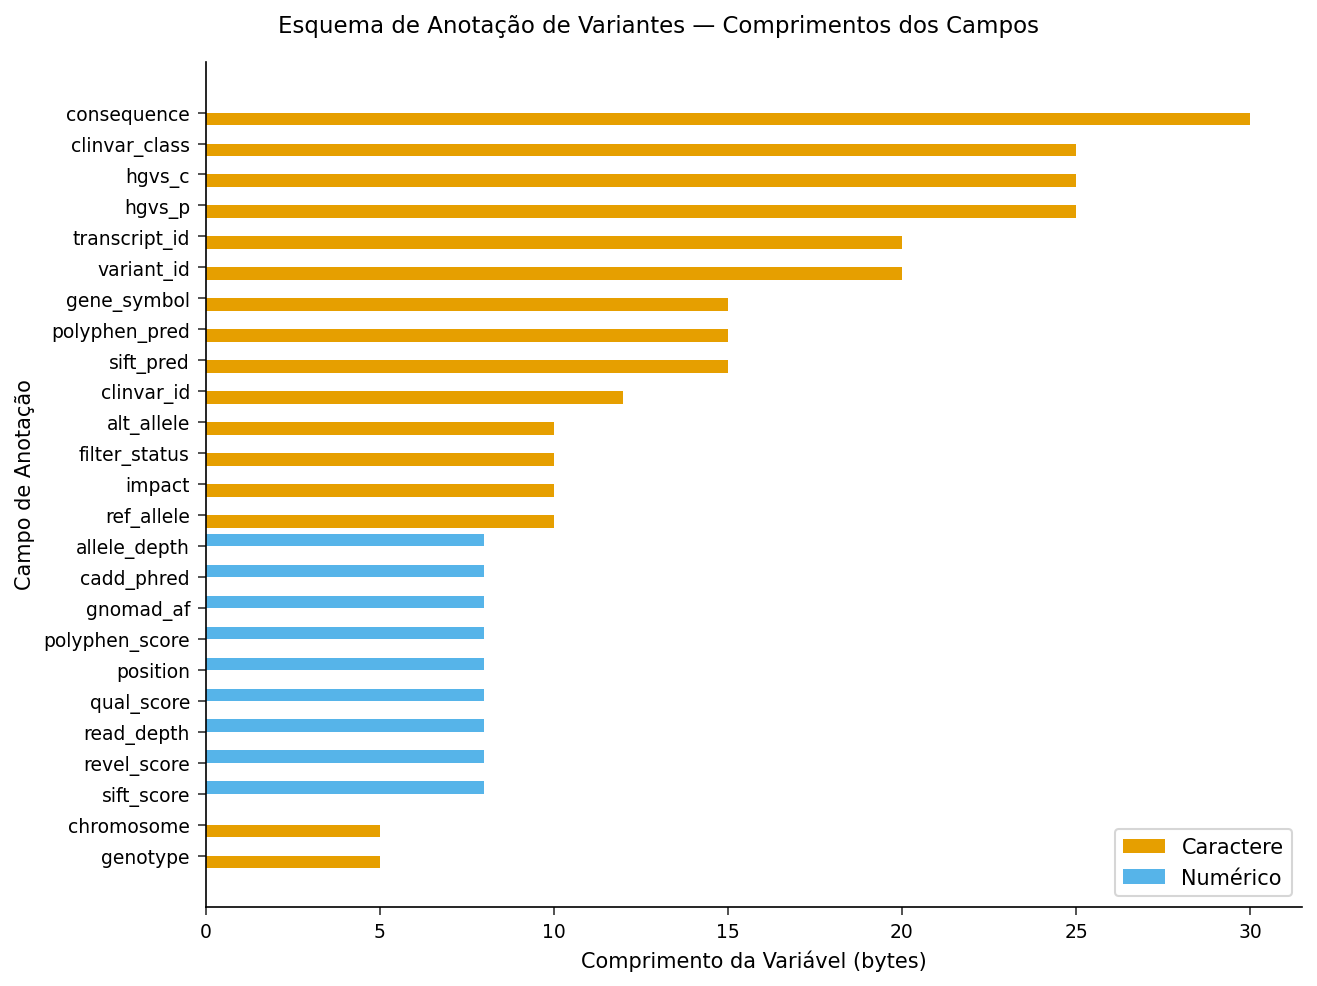

In [5]:
/* --------------------------------------------------------
   Distribuição de tipo e comprimento das variáveis.
   Captura os metadados do esquema de anotação com PROC
   CONTENTS OUT=, depois plota os comprimentos dos campos
   por tipo. Os códigos TYPE mapeiam 1 -> Numérico,
   2 -> Caractere para a legenda.
   -------------------------------------------------------- */
PROCEDIMENTO CONTEÚDO DADOS=variant_annotations out=schema_lengths NOPRINT;
EXECUTAR;

DADOS schema_lengths;
    DEFINIR schema_lengths;
    COMPRIMENTO type_label $12;
    SE TYPE = 1 ENTÃO type_label = 'Numérico';
    SENÃO type_label = 'Caractere';
    RÓTULO type_label="Tipo de Dado";
EXECUTAR;

PROCEDIMENTO SGPLOT DADOS=schema_lengths;
    HBAR NAME / RESPONSE=COMPRIMENTO GROUP=type_label
        CATEGORYORDER=respdesc;
    XAXIS RÓTULO="Comprimento da Variável (bytes)";
    YAXIS RÓTULO="Campo de Anotação";
    TÍTULO "Esquema de Anotação de Variantes — Comprimentos dos Campos";
EXECUTAR;

---

In [6]:
/* --------------------------------------------------------
   PROC CONTENTS: Documenta o esquema completo de anotação
   de variantes — tipos, comprimentos e rótulos de todos os
   25 campos. Captura os metadados das variáveis com OUT=
   para que etapas subsequentes possam validar o esquema
   programaticamente.
   -------------------------------------------------------- */
PROCEDIMENTO CONTEÚDO DADOS=variant_annotations out=variant_schema NOPRINT;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=variant_schema RÓTULO;
    VARIÁVEL NAME TYPE COMPRIMENTO VARNUM RÓTULO;
    RÓTULO NAME="Nome" TYPE="Tipo" COMPRIMENTO="Comprimento"
          VARNUM="Ordem da Variável" RÓTULO="Rótulo";
    TÍTULO "Conjunto de Dados de Anotação de Variantes — Esquema Completo";
EXECUTAR;

                                   Resumo das Métricas de Qualidade de Sequenciamento                                   

                             Conjunto de Dados de Anotação de Variantes — Esquema Completo                              

  Obs            Nome  Tipo  Comprimento   Ordem da Variável                             Rótulo
    1  allele_depth       1            8                  22  Profundidade do Alelo Alternativo
    2  alt_allele         2           10                   5  Alelo Alternativo
    3  cadd_phred         1            8                  19  Escore CADD Phred
    4  chromosome         2            5                   2  Cromossomo
    5  clinvar_class      2           25                  13  Classificação ClinVar
    6  clinvar_id         2           12                  14  Acesso ClinVar
    7  consequence        2           30                   8  Consequência (Sequence Ontology)
    8  filter_status      2           10                  25  Status do Fil


NOTE: PROC CONTENTS data=variant_annotations

NOTE: PROC CONTENTS: OUT=variant_schema created with 25 variables
NOTE: PROC CONTENTS: data=variant_annotations obs=100 vars=25 (NOPRINT)
NOTE: PROC PRINT data=variant_schema

NOTE: PROC PRINT completed: 25 observations printed, 5 variables


In [7]:
/* --------------------------------------------------------
   PROC CONTENTS: Documenta o esquema do painel gênico
   -------------------------------------------------------- */
PROCEDIMENTO CONTEÚDO DADOS=gene_panel out=panel_schema NOPRINT;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=panel_schema RÓTULO;
    VARIÁVEL NAME TYPE COMPRIMENTO VARNUM RÓTULO;
    RÓTULO NAME="Nome" TYPE="Tipo" COMPRIMENTO="Comprimento"
          VARNUM="Ordem da Variável" RÓTULO="Rótulo";
    TÍTULO "Definição do Painel Gênico — Esquema";
EXECUTAR;

                             Conjunto de Dados de Anotação de Variantes — Esquema Completo                              

                                          Definição do Painel Gênico — Esquema                                          

  Obs                 Nome  Tipo  Comprimento   Ordem da Variável                     Rótulo
    1  chromosome              2            5                   3  Cromossomo
    2  disease_association     2           50                   7  Doença Associada
    3  end_pos                 1            8                   5  Posição Final do Gene
    4  gene_name               2           60                   2  Nome Completo do Gene
    5  gene_symbol             2           15                   1  Símbolo Gênico HGNC
    6  inheritance             2            5                   8  Padrão de Herança
    7  panel_name              2           30                   6  Painel Gênico Clínico
    8  start_pos               1            8                 


NOTE: PROC CONTENTS data=gene_panel

NOTE: PROC CONTENTS: OUT=panel_schema created with 8 variables
NOTE: PROC CONTENTS: data=gene_panel obs=15 vars=8 (NOPRINT)
NOTE: PROC PRINT data=panel_schema

NOTE: PROC PRINT completed: 8 observations printed, 5 variables


In [8]:
/* --------------------------------------------------------
   PROC CONTENTS: Documenta o esquema das métricas de QC
   -------------------------------------------------------- */
PROCEDIMENTO CONTEÚDO DADOS=quality_metrics out=qc_schema NOPRINT;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=qc_schema RÓTULO;
    VARIÁVEL NAME TYPE COMPRIMENTO VARNUM RÓTULO;
    RÓTULO NAME="Nome" TYPE="Tipo" COMPRIMENTO="Comprimento"
          VARNUM="Ordem da Variável" RÓTULO="Rótulo";
    TÍTULO "Métricas de Qualidade de Sequenciamento — Esquema";
EXECUTAR;

                                          Definição do Painel Gênico — Esquema                                          

                                   Métricas de Qualidade de Sequenciamento — Esquema                                    

  Obs               Nome  Tipo  Comprimento   Ordem da Variável                             Rótulo
    1  contamination_est     1            8                  10  Contaminação Estimada
    2  het_hom_ratio         1            8                   9  Razão Het/Hom
    3  mean_coverage         1            8                   4  Cobertura Média do Alvo
    4  pct_target_100x       1            8                   6  Percentual de Bases >= 100x
    5  pct_target_20x        1            8                   5  Percentual de Bases >= 20x
    6  platform              2           15                   3  Plataforma de Sequenciamento
    7  qc_status             2           10                  11  Status de QC (Aprovado/Reprovado)
    8  run_id           


NOTE: PROC CONTENTS data=quality_metrics

NOTE: PROC CONTENTS: OUT=qc_schema created with 11 variables
NOTE: PROC CONTENTS: data=quality_metrics obs=50 vars=11 (NOPRINT)
NOTE: PROC PRINT data=qc_schema

NOTE: PROC PRINT completed: 11 observations printed, 5 variables


In [9]:
/* --------------------------------------------------------
   Validação do esquema: verifica se os campos de anotação
   atendem aos requisitos do pipeline para a interpretação
   ACMG. Lê os metadados do PROC CONTENTS OUT=, onde TYPE=1
   denota numérico e TYPE=2 denota caractere.
   -------------------------------------------------------- */
DADOS schema_validation;
    DEFINIR variant_schema;
    COMPRIMENTO requirement $80 status $12;
    /* Os campos de escore numérico devem ser numéricos (TYPE=1) */
    SE NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        E_LÓGICO TYPE ne 1 ENTÃO FAZER;
        requirement = "Deve ser numérico para limiares de escore";
        status = "REPROVADO";
    FIM;
    SENÃO SE NAME IN ('gnomad_af' 'sift_score' 'polyphen_score'
        'cadd_phred' 'revel_score' 'qual_score'
        'allele_depth' 'read_depth' 'position')
        E_LÓGICO TYPE = 1 ENTÃO FAZER;
        requirement = "Tipo numérico confirmado";
        status = "APROVADO";
    FIM;
    /* A classe ClinVar precisa de comprimento de caractere suficiente */
    SENÃO SE NAME = 'clinvar_class' E_LÓGICO COMPRIMENTO < 25 ENTÃO FAZER;
        requirement = "Mín. $25 para o texto completo de classificação";
        status = "REPROVADO";
    FIM;
    SENÃO SE NAME = 'clinvar_class' ENTÃO FAZER;
        requirement = "Comprimento de caractere suficiente";
        status = "APROVADO";
    FIM;
    /* Todos os campos devem ter um rótulo para o dicionário de dados */
    SENÃO SE RÓTULO = '' ENTÃO FAZER;
        requirement = "Rótulo obrigatório para o dicionário de dados";
        status = "REPROVADO";
    FIM;
    SENÃO FAZER;
        requirement = "Validação geral";
        status = "APROVADO";
    FIM;
EXECUTAR;

PROCEDIMENTO IMPRIMIR DADOS=schema_validation RÓTULO;
    VARIÁVEL NAME TYPE COMPRIMENTO RÓTULO requirement status;
    RÓTULO NAME="Nome" TYPE="Tipo" COMPRIMENTO="Comprimento"
          RÓTULO="Rótulo" requirement="Requisito" status="Status";
    TÍTULO "Relatório de Validação de Esquema do Pipeline ACMG";
EXECUTAR;

                                   Relatório de Validação de Esquema do Pipeline ACMG                                   

  Obs            Nome  Tipo  Comprimento                             Rótulo                            Requisito    Status
    1  allele_depth       1            8  Profundidade do Alelo Alternativo  Tipo numérico confirmado             APROVADO
    2  alt_allele         2           10  Alelo Alternativo                  Validação geral                      APROVADO
    3  cadd_phred         1            8  Escore CADD Phred                  Tipo numérico confirmado             APROVADO
    4  chromosome         2            5  Cromossomo                         Validação geral                      APROVADO
    5  clinvar_class      2           25  Classificação ClinVar              Comprimento de caractere suficiente  APROVADO
    6  clinvar_id         2           12  Acesso ClinVar                     Validação geral                      APROVADO
    7  consequenc


NOTE: DATA schema_validation


NOTE: Read 25 rows from variant_schema.
NOTE: Wrote schema_validation (25 rows, 18 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=schema_validation

NOTE: PROC PRINT completed: 25 observations printed, 6 variables


---

### Interpretação

O esquema de anotação de variantes contém 25 campos que abrangem coordenadas genômicas, previsões funcionais, frequências populacionais e indicadores de qualidade por amostra. Todos os nove campos de escore numérico (frequência alélica do gnomAD, SIFT, PolyPhen-2, CADD, REVEL, escore de qualidade, profundidade alélica, profundidade de leitura e posição genômica) estão corretamente tipados como numéricos, permitindo que o mecanismo de interpretação ACMG aplique filtragem baseada em limiares sem conversão de tipo. O campo clinvar_class, com $25, acomoda a mais longa cadeia de classificação do ClinVar (Uncertain_significance, com 24 caracteres). Cada campo de anotação carrega um rótulo descritivo, satisfazendo a exigência do dicionário de dados do laboratório clínico sob os requisitos de acreditação CAP. O esquema do painel de genes mapeia 15 genes de predisposição ao câncer com padrões de herança e associações a doenças, fornecendo o quadro de referência para a anotação de variante para gene. O conjunto de dados de métricas de QC de sequenciamento documenta 50 amostras em 5 execuções, com estimativas de contaminação e limiares de cobertura que condicionam a confiabilidade da chamada de variantes. Este pacote de documentação de esquema apoia o dossiê de validação do laboratório para a submissão ao New York State CLEP.

---

In [10]:
/* --------------------------------------------------------
   Exporta a documentação do esquema de variantes e o
   relatório de validação para acreditação laboratorial
   -------------------------------------------------------- */
PROCEDIMENTO EXPORT DADOS=variant_schema
    OUTFILE='variant_annotation_schema.csv'
    DBMS=csv REPLACE;
EXECUTAR;

PROCEDIMENTO EXPORT DADOS=schema_validation
    OUTFILE='acmg_schema_validation.csv'
    DBMS=csv REPLACE;
EXECUTAR;


NOTE: PROC EXPORT data=variant_schema outfile=variant_annotation_schema.csv

NOTE: Exported 25 rows to variant_annotation_schema.csv.
NOTE: PROC EXPORT data=schema_validation outfile=acmg_schema_validation.csv

NOTE: Exported 25 rows to acmg_schema_validation.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Desenvolvido com <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>